# Trends, Overlap, outliers, correlations, importance

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/melbourne/*.csv")[0]
TARGET = "Price"
df = pd.read_csv(DATA_FILE)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce") # sale date: text - datetime
df["Postcode"] = df["Postcode"].astype("Int64").astype(str) # a code, not a quantity - text
LAT = next(c for c in df.columns if c.lower().startswith("lat"))# the Kaggle file spells it "Lattitude"
LON = next(c for c in df.columns if c.lower().startswith("long"))

num_cols, cat_cols = split_columns(df, TARGET)# feature lists WITHOUT the target (Date is excluded from both)
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(13580, 21) | numeric features: 11 | categorical features: 8


## 3a) Major trends

Most correlated with Price: ['Rooms', 'Bedroom2', 'Bathroom', 'YearBuilt', 'Car', 'Lattitude']


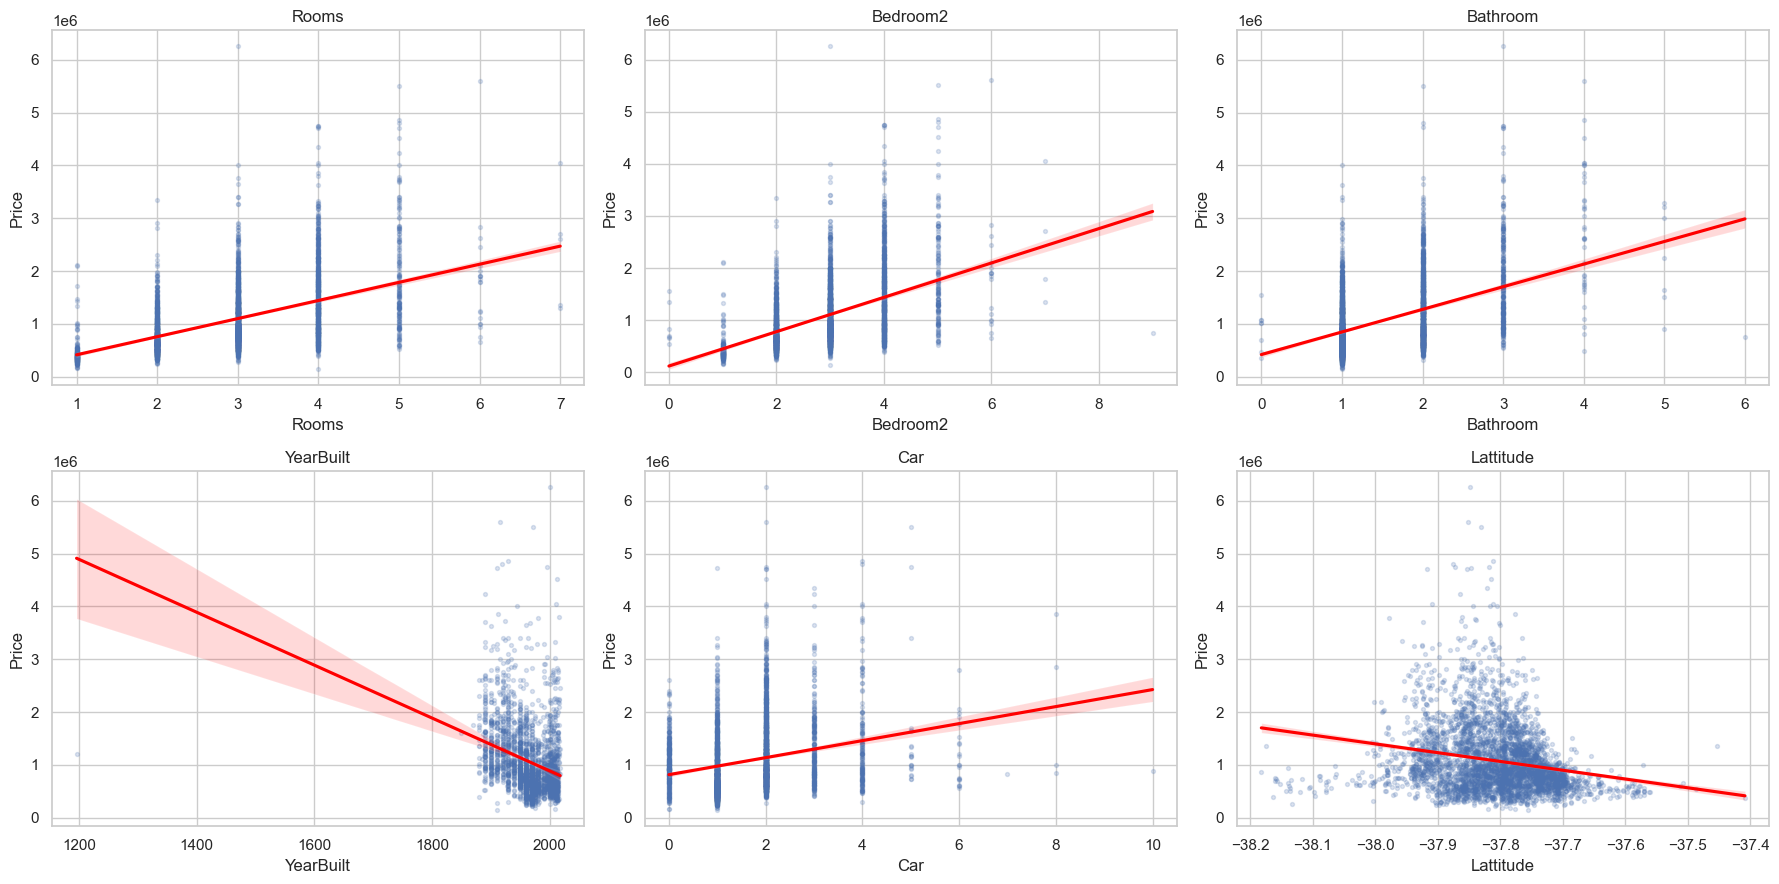

In [2]:
top = df[num_cols].corrwith(df[TARGET]).abs().sort_values(ascending=False).head(6).index.tolist()
print("Most correlated with Price:", top)
s = df.sample(min(4000, len(df)), random_state=1)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), top):
    sns.regplot(data=s, x=col, y=TARGET, scatter_kws={"alpha": .2, "s": 8}, line_kws={"color": "red"}, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

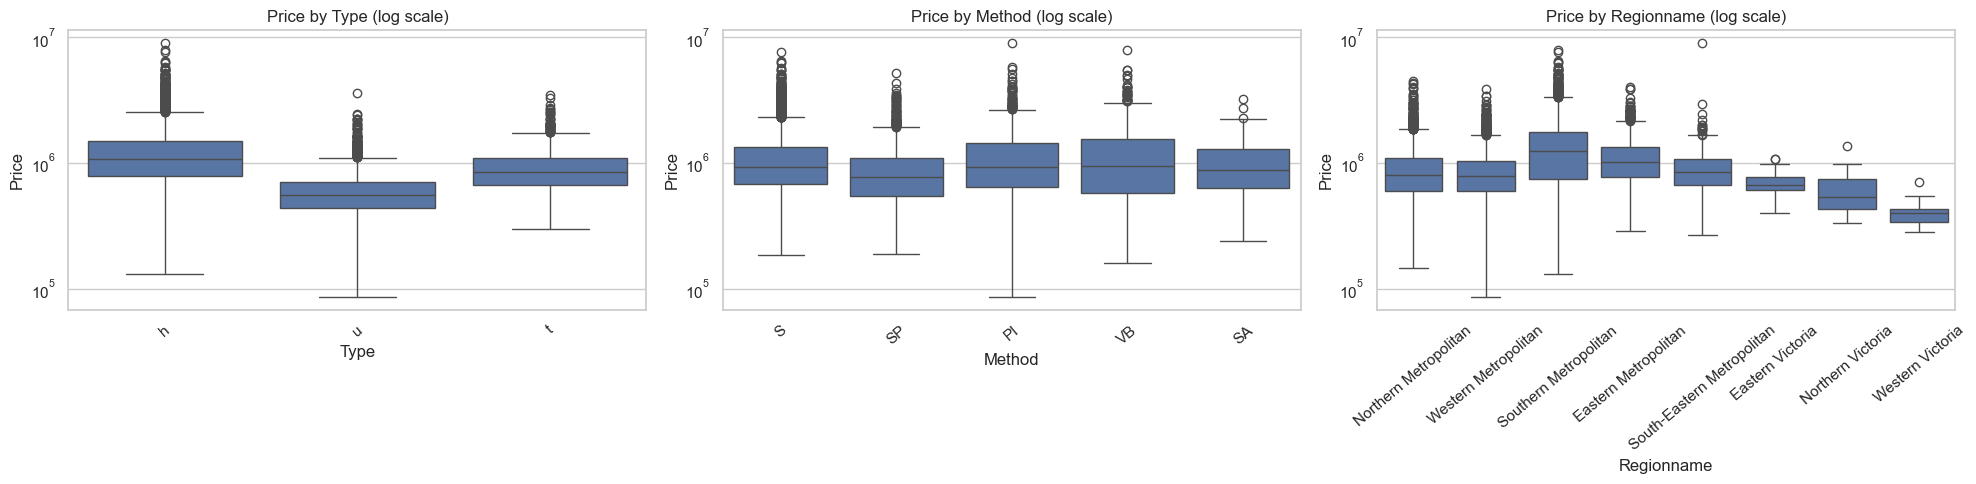

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, ["Type", "Method", "Regionname"]):
    sns.boxplot(data=df, x=col, y=TARGET, ax=ax); ax.set_yscale("log"); ax.tick_params(axis="x", rotation=40); ax.set_title(f"Price by {col} (log scale)")
plt.tight_layout(); plt.show()

## 3b) Overlapping Data

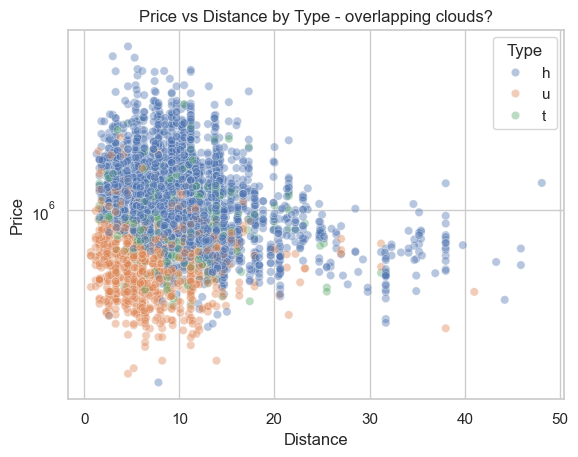

,R2 of a straight line with Price
Rooms,0.247
Bedroom2,0.227
Bathroom,0.218
YearBuilt,0.105
Car,0.057
Lattitude,0.045
Longtitude,0.041
Distance,0.026
BuildingArea,0.008
Propertycount,0.002


In [4]:
sns.scatterplot(data=s, x="Distance", y=TARGET, hue="Type", alpha=.4); plt.yscale("log"); plt.title("Price vs Distance by Type - overlapping clouds?"); plt.show()
r2 = {}
for col in num_cols:
    d = df[[col, TARGET]].dropna()
    r2[col] = d.corr().iloc[0, 1] ** 2
display(pd.Series(r2).sort_values(ascending=False).round(3).to_frame("R2 of a straight line with Price"))

## 3c) Outliers and Noise

,n_outliers,pct,n_|z|>3,n_MAD_outliers,lower_fence,upper_fence,min,max
column,,,,,,,,
Rooms,682,5.02,86,1.0,0.50,4.50,1.00000,1.000000e+01
Distance,411,3.03,246,280.0,-4.25,23.35,0.00000,4.810000e+01
Bedroom2,655,4.82,99,5.0,0.50,4.50,0.00000,2.000000e+01
Bathroom,143,1.05,143,NaN,-0.50,3.50,0.00000,8.000000e+00
Car,644,4.76,138,13.0,-0.50,3.50,0.00000,1.000000e+01
Landsize,368,2.71,24,294.0,-534.00,1362.00,0.00000,4.330140e+05
BuildingArea,353,4.95,4,231.0,-28.50,295.50,0.00000,4.451500e+04
YearBuilt,6,0.07,6,1.0,1851.50,2087.50,1196.00000,2.018000e+03
Lattitude,262,1.93,139,116.0,-38.01,-37.61,-38.18255,-3.740853e+01


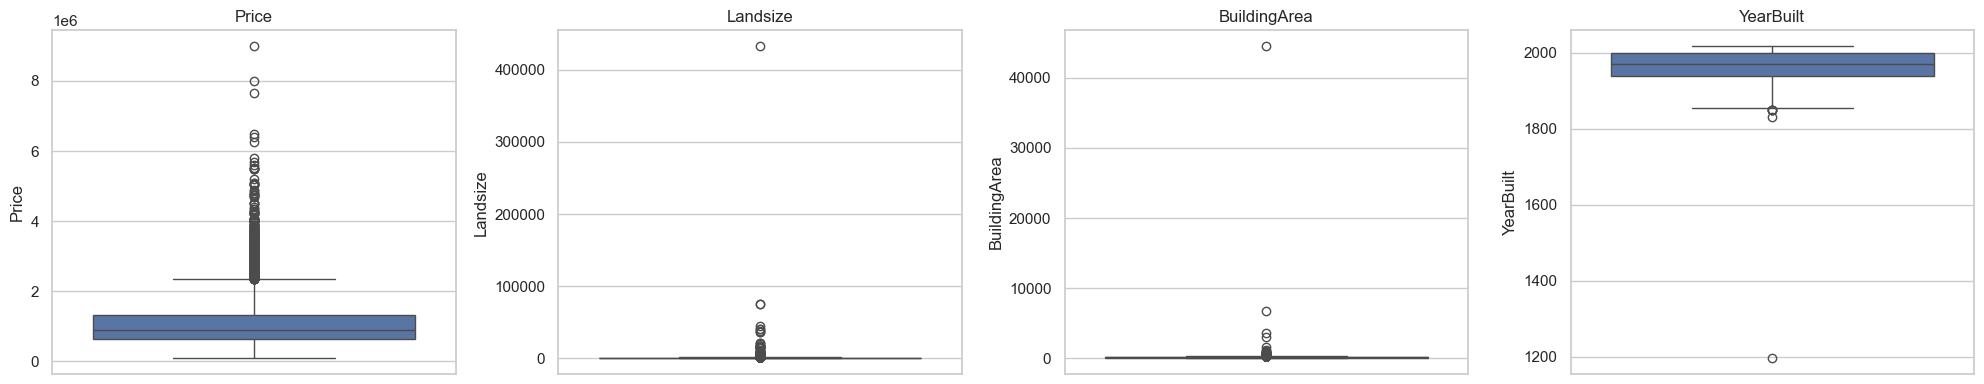

In [5]:
cols = num_cols + [TARGET]
res = iqr_outliers(df, cols).join(zscore_outliers(df, cols)).join(mad_outliers(df, cols))
display(res[["n_outliers", "pct", "n_|z|>3", "n_MAD_outliers", "lower_fence", "upper_fence", "min", "max"]])
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, col in zip(ax, [TARGET, "Landsize", "BuildingArea", "YearBuilt"]):
    sns.boxplot(y=df[col], ax=a); a.set_title(col)
plt.tight_layout(); plt.show()

In [6]:
out = pd.DataFrame({"isolation_forest": isolation_forest_flags(df, cols), "elliptic_envelope": elliptic_flags(df, cols)})
print(out.sum(), "\nflagged by BOTH:", int(out.all(axis=1).sum()))
display(df[out.all(axis=1)].sort_values(TARGET, ascending=False).head(10))
display(df.nlargest(5, "Landsize")[["Suburb", "Type", "Rooms", "Price", "Landsize", "BuildingArea"]])
display(df.nsmallest(5, "YearBuilt")[["Suburb", "Type", "Price", "YearBuilt"]])

isolation_forest     272
elliptic_envelope    272
dtype: int64 
flagged by BOTH: 73


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
7692,Canterbury,49 Mangarra Rd,5,h,8000000.0,VB,Sotheby's,2017-05-13,9.0,3126,5.0,5.0,4.0,2079.0,464.3,1880.0,Boroondara,-37.81790,145.06940,Southern Metropolitan,3265.0
9575,Hawthorn,49 Lisson Gr,4,h,7650000.0,S,Abercromby's,2017-06-17,5.3,3122,4.0,2.0,4.0,1690.0,284.0,1863.0,Boroondara,-37.82652,145.03052,Southern Metropolitan,11308.0
3616,Kew,15 Barry St,6,h,6500000.0,S,Jellis,2016-08-13,5.6,3101,6.0,6.0,3.0,1334.0,365.0,1890.0,Boroondara,-37.80290,145.02670,Southern Metropolitan,10331.0
12557,Middle Park,136 Page St,5,h,6400000.0,S,Marshall,2017-09-09,3.0,3206,5.0,2.0,1.0,553.0,308.0,1920.0,NaN,-37.84908,144.95753,Southern Metropolitan,2019.0
7554,Brighton,161 Church St,5,h,5800000.0,PI,Castran,2017-04-08,11.2,3186,5.0,4.0,4.0,1276.0,NaN,1880.0,Bayside,-37.91640,144.99740,Southern Metropolitan,10579.0
5631,South Yarra,18 Avoca St,4,h,5700000.0,S,Castran,2016-11-12,3.3,3141,4.0,2.0,0.0,292.0,272.0,1880.0,Stonnington,-37.83770,144.98940,Southern Metropolitan,14887.0
251,Armadale,367 Dandenong Rd,6,h,5525000.0,S,Marshall,2016-09-17,6.3,3143,5.0,3.0,4.0,1491.0,516.0,1935.0,Stonnington,-37.86020,145.01300,Southern Metropolitan,4836.0
9179,Hawthorn,17 Fairview St,5,h,5510000.0,S,RT,2017-06-03,5.3,3122,5.0,2.0,5.0,820.0,300.0,1971.0,Boroondara,-37.83031,145.02973,Southern Metropolitan,11308.0
6340,Toorak,10 Myoora Rd,4,h,5500000.0,VB,Marshall,2016-12-03,4.6,3142,4.0,3.0,2.0,691.0,374.0,2000.0,Stonnington,-37.84310,145.02100,Southern Metropolitan,7217.0
6345,Toorak,684 Orrong Rd,4,h,5500000.0,S,Marshall,2017-03-04,4.6,3142,4.0,4.0,5.0,877.0,332.0,1923.0,Stonnington,-37.84470,145.01340,Southern Metropolitan,7217.0


,Suburb,Type,Rooms,Price,Landsize,BuildingArea
11020,Fitzroy,h,3,2700000.0,433014.0,NaN
10504,Silvan,h,3,1085000.0,76000.0,NaN
687,Balwyn North,h,3,2000000.0,75100.0,NaN
13245,New Gisborne,h,5,1355000.0,44500.0,44515.0
5194,Reservoir,h,3,572000.0,41400.0,NaN


,Suburb,Type,Price,YearBuilt
9968,Mount Waverley,h,1200000.0,1196.0
2079,Collingwood,u,855000.0,1830.0
2554,Fitzroy,h,677000.0,1850.0
4843,Prahran,u,841000.0,1850.0
5405,Richmond,h,1600000.0,1850.0


## 3d) Correlation and Phi-K

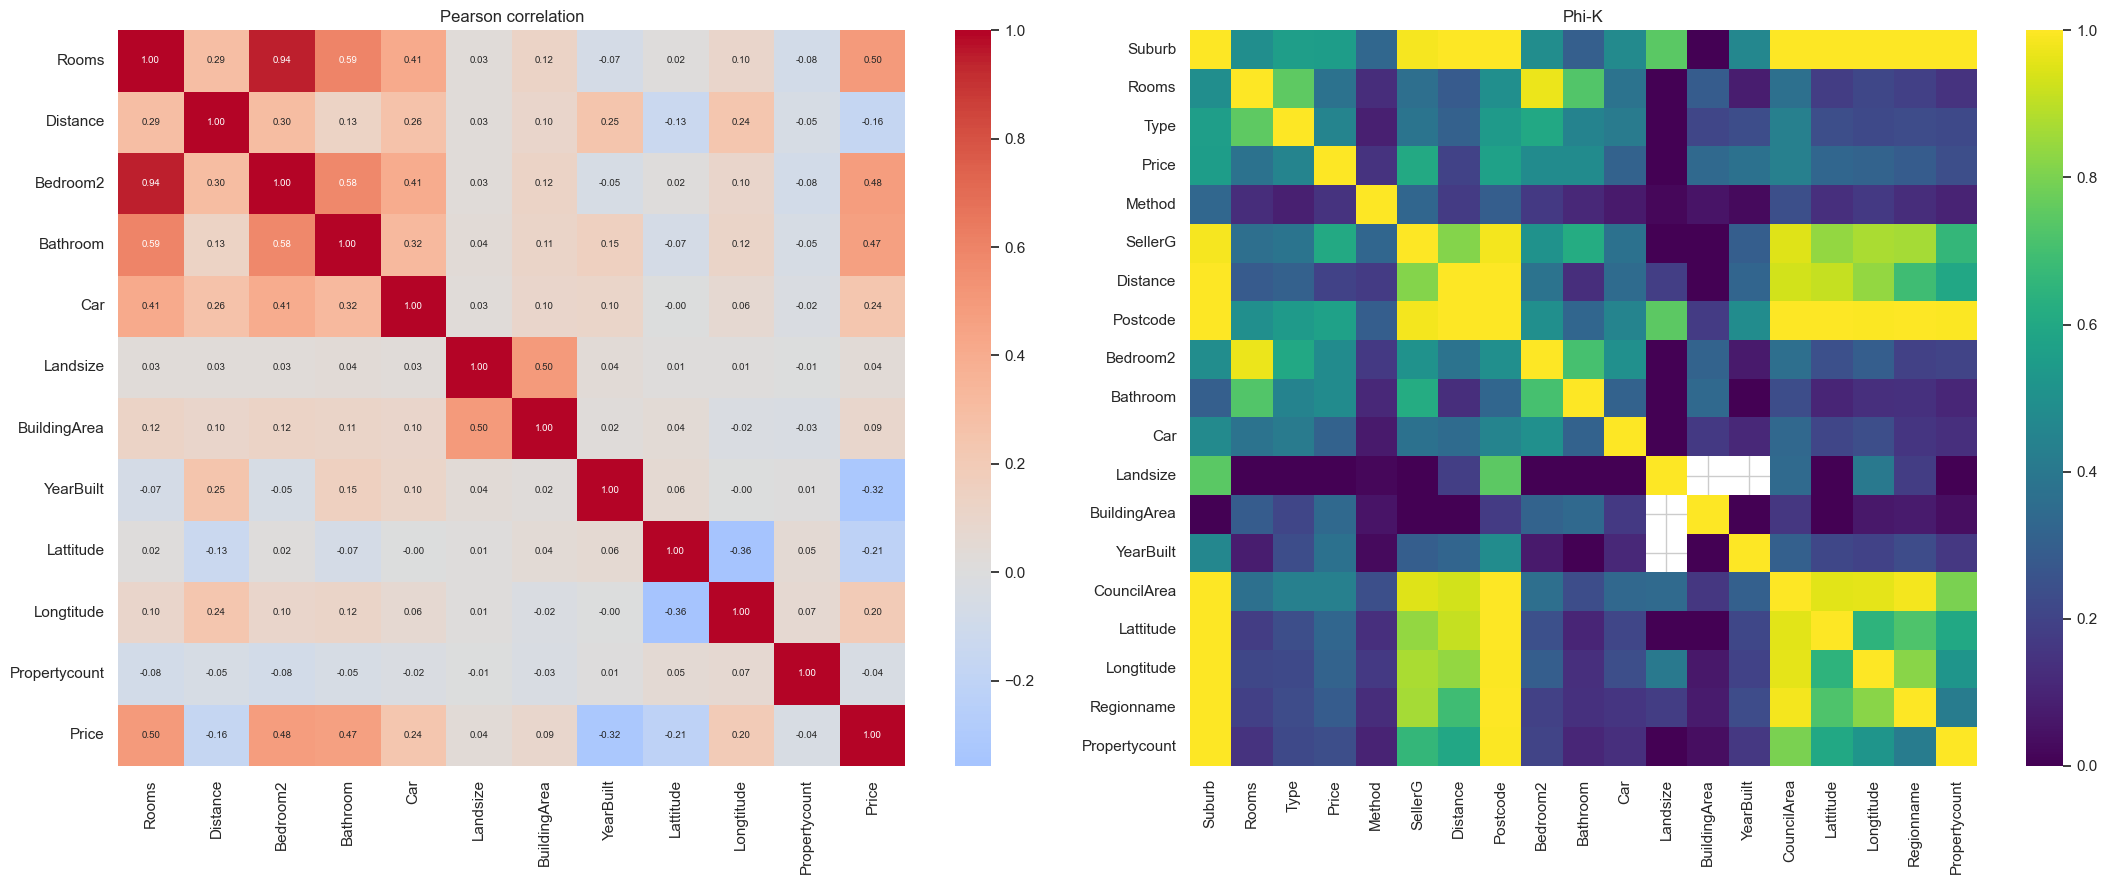

,Phi-K with Price
SellerG,0.605
Postcode,0.569
Suburb,0.553
Bedroom2,0.480
Bathroom,0.477
Type,0.452
CouncilArea,0.434
Rooms,0.378
YearBuilt,0.372
BuildingArea,0.336


In [7]:
pk, method = association_matrix(df.drop(columns=["Address", "Date"]), interval_cols=[c for c in num_cols + [TARGET]])
fig, ax = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(df[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7}, ax=ax[0]); ax[0].set_title("Pearson correlation")
sns.heatmap(pk, cmap="viridis", vmin=0, vmax=1, ax=ax[1]); ax[1].set_title(method)
plt.tight_layout(); plt.show()
display(pk[TARGET].drop(TARGET).sort_values(ascending=False).round(3).to_frame(f"{method} with {TARGET}"))

## 3e) Feature Importance

Excluded high-cardinality columns: ['Suburb', 'Address', 'SellerG', 'Postcode'] | matrix: (13580, 60)


,F_regression,mutual_info,RF_importance,RFE_rank
Regionname_Southern Metropolitan,993.611,0.064,0.200,36
Rooms,2602.296,0.207,0.132,1
Distance,211.795,0.195,0.129,1
BuildingArea,1683.247,0.190,0.088,3
Landsize,12.884,0.143,0.088,24
Type_h,1518.164,0.143,0.060,1
Longtitude,356.490,0.151,0.058,11
Lattitude,399.322,0.131,0.054,4
Type_u,1463.824,0.170,0.047,5
Bathroom,2266.465,0.144,0.034,2


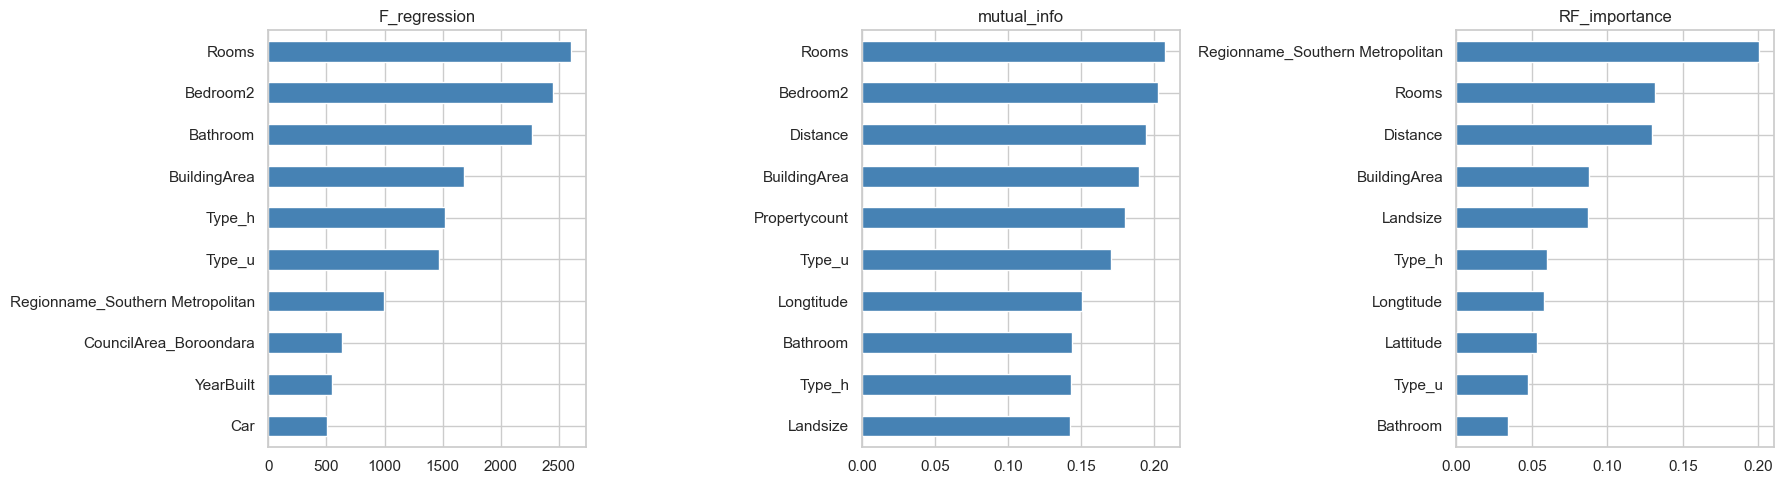

In [8]:
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X, y, dropped = make_model_matrix(df.dropna(subset=[TARGET]), TARGET)
print("Excluded high-cardinality columns:", dropped, "| matrix:", X.shape)
Xs = X.sample(min(8000, len(X)), random_state=42); ys = y.loc[Xs.index]
imp = pd.DataFrame({
    "F_regression": f_regression(Xs, ys)[0],
    "mutual_info": mutual_info_regression(Xs, ys, random_state=42),
    "RF_importance": RandomForestRegressor(200, random_state=42, n_jobs=-1).fit(Xs, ys).feature_importances_,
}, index=Xs.columns)
imp["RFE_rank"] = RFE(LinearRegression(), n_features_to_select=5).fit(StandardScaler().fit_transform(Xs), ys).ranking_
imp = imp.sort_values("RF_importance", ascending=False); display(imp.round(3).head(15))
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, col in zip(ax, ["F_regression", "mutual_info", "RF_importance"]): imp[col].sort_values().tail(10).plot.barh(ax=a, color="steelblue"); a.set_title(col)
plt.tight_layout(); plt.show()

## 3f) Additional Notes